In [1]:
import pandas as pd
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
x=df[['Annual Income (k$)','Spending Score (1-100)']]
print(x)
print(df.iloc[:,3:])

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]
     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196             

In [3]:
print(df.isnull().sum())
# df[[df['age']>0]]['cg']

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


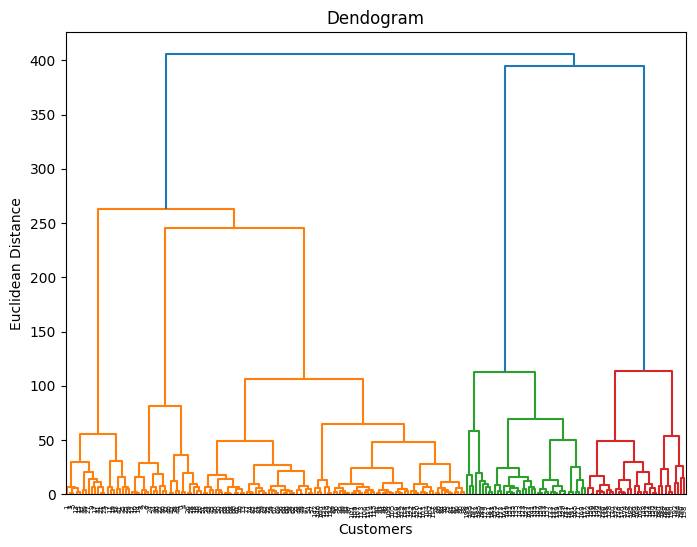

In [13]:
import scipy.cluster.hierarchy as ch
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
dendeogram=ch.dendrogram(ch.linkage(x,method='ward'))
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.title('Dendogram')
plt.show()

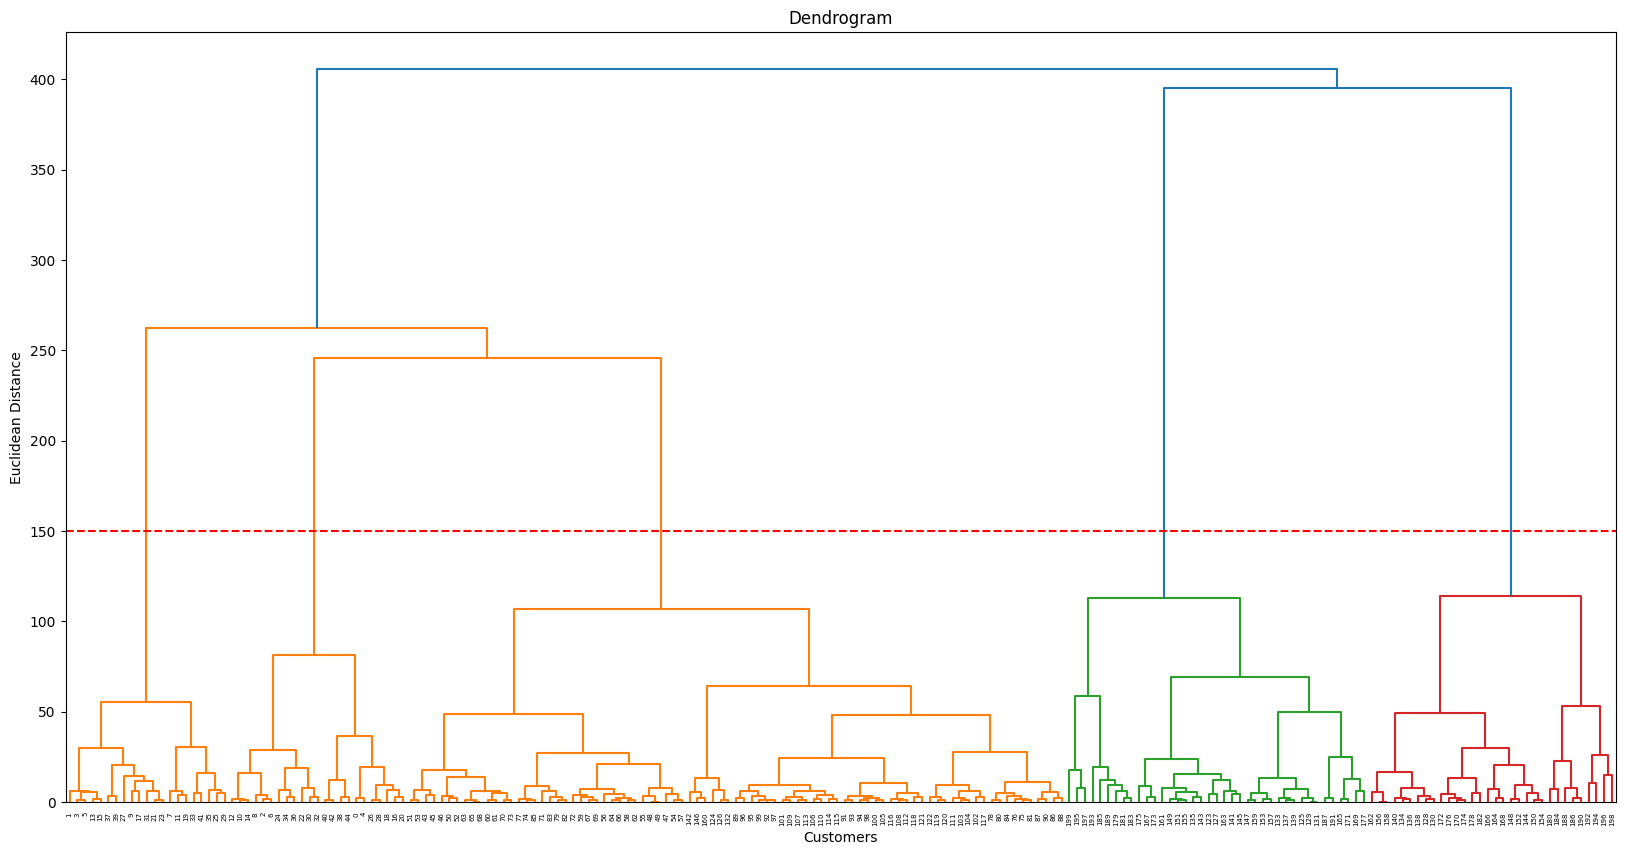

In [5]:
import scipy.cluster.hierarchy as ch
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))   # Set size FIRST

dendrogram = ch.dendrogram(ch.linkage(x, method='ward'))

plt.axhline(y=150, color='r', linestyle='--')  # horizontal cut line

plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.title('Dendrogram')
plt.show()


In [6]:
from sklearn.cluster import AgglomerativeClustering
agc=AgglomerativeClustering(n_clusters=5,metric="euclidean",linkage='ward')
y_hc=agc.fit_predict(x)
print(y_hc)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


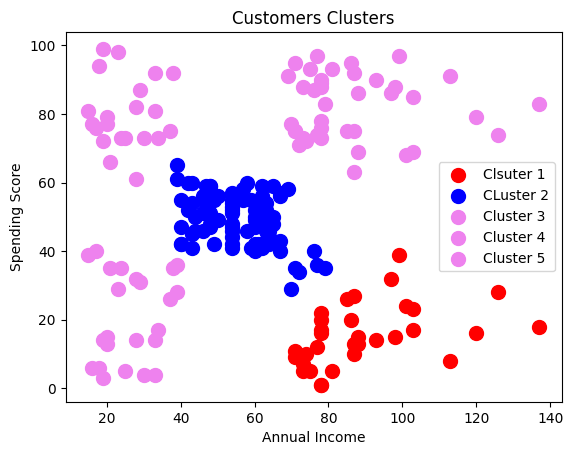

In [7]:
plt.scatter(x.iloc[y_hc==0,0],x.iloc[y_hc==0,1],c='red',s=100,label='Clsuter 1')
plt.scatter(x.iloc[y_hc==1,0],x.iloc[y_hc==1,1],c='blue',s=100,label='CLuster 2')
plt.scatter(x.iloc[y_hc==2,0],x.iloc[y_hc==2,1],c='violet',s=100,label='Cluster 3')
plt.scatter(x.iloc[y_hc==3,0],x.iloc[y_hc==3,1],c='violet',s=100,label='Cluster 4')
plt.scatter(x.iloc[y_hc==4,0],x.iloc[y_hc==4,1],c='violet',s=100,label='Cluster 5')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customers Clusters')
plt.legend()

In [8]:
from sklearn.metrics import silhouette_score 
score=silhouette_score(x,y_hc)
print("silhouette score ",score)

silhouette score  0.5529945955148897
